In [59]:
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

# Load the dataset
df = pd.read_csv('Student_performance_data _.csv')

# Display the first few rows
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [60]:
# Create a binary target variable based on GPA
# GPA >= 2.5: Doesn't need academic guidance (0)
# GPA < 2.5: Needs academic guidance (1)
threshold = 2.5
df['NeedsGuidance'] = (df['GPA'] < threshold).astype(int)

print(f"\nAcademic Guidance Distribution (Threshold: GPA < {threshold}):")
print(df['NeedsGuidance'].value_counts())
print(f"\n0 = Doesn't Need Academic Guidance (GPA >= {threshold})")
print(f"1 = Needs Academic Guidance (GPA < {threshold})")


Academic Guidance Distribution (Threshold: GPA < 2.5):
NeedsGuidance
1    1686
0     706
Name: count, dtype: int64

0 = Doesn't Need Academic Guidance (GPA >= 2.5)
1 = Needs Academic Guidance (GPA < 2.5)


In [61]:
from sklearn.preprocessing import StandardScaler

# Drop StudentID and original GPA/GradeClass columns
columns_to_drop = ['StudentID', 'GPA', 'GradeClass']
df_features = df.drop(columns_to_drop, axis=1)

# Separate features and target
X = df_features.drop('NeedsGuidance', axis=1)
y = df_features['NeedsGuidance']
# One-hot encode categorical variables
categorical_columns = ['Gender', 'Ethnicity', 'ParentalEducation', 'ParentalSupport']
X_encoded = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

print(f"\nFeatures after encoding: {X_encoded.shape[1]}")
print(f"Feature names: {X_encoded.columns.tolist()}")


Features after encoding: 20
Feature names: ['Age', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'Gender_1', 'Ethnicity_1', 'Ethnicity_2', 'Ethnicity_3', 'ParentalEducation_1', 'ParentalEducation_2', 'ParentalEducation_3', 'ParentalEducation_4', 'ParentalSupport_1', 'ParentalSupport_2', 'ParentalSupport_3', 'ParentalSupport_4']


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Train initial Random Forest model
print("\n" + "="*50)
print("INITIAL MODEL (Without SMOTE)")
print("="*50)

rf_initial = RandomForestClassifier(n_estimators=100, random_state=42)
rf_initial.fit(X_train, y_train)

y_pred_initial = rf_initial.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_initial):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_initial, 
                          target_names=["No Guidance Needed", "Needs Guidance"]))


Training set size: 1913
Test set size: 479

INITIAL MODEL (Without SMOTE)

Accuracy: 0.9165

Classification Report:
                    precision    recall  f1-score   support

No Guidance Needed       0.86      0.87      0.86       145
    Needs Guidance       0.94      0.94      0.94       334

          accuracy                           0.92       479
         macro avg       0.90      0.90      0.90       479
      weighted avg       0.92      0.92      0.92       479



In [63]:
# Apply SMOTE to handle class imbalance
print("\n" + "="*50)
print("MODEL WITH SMOTE")
print("="*50)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nTraining set size after SMOTE: {X_train_smote.shape[0]}")
print(f"Class distribution after SMOTE:")
print(f"  Doesn't Need Guidance: {np.sum(y_train_smote == 0)}")
print(f"  Needs Guidance: {np.sum(y_train_smote == 1)}")


MODEL WITH SMOTE

Training set size after SMOTE: 2704
Class distribution after SMOTE:
  Doesn't Need Guidance: 1352
  Needs Guidance: 1352


In [90]:
# Train model with SMOTE
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test)
print(f"\nAccuracy after SMOTE: {accuracy_score(y_test, y_pred_smote):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote, 
                          target_names=["No Guidance Needed", "Needs Guidance"]))

# Feature Importance Analysis
print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*50)

importances = rf_smote.feature_importances_
feature_names = X_encoded.columns

feat_importances = pd.Series(importances, index=feature_names)
feat_importances = feat_importances.sort_values(ascending=False)

print("\nIndividual Contribution (Top 5 Features)")
print(feat_importances.head(5))


Accuracy after SMOTE: 0.9144

Classification Report:
                    precision    recall  f1-score   support

No Guidance Needed       0.84      0.89      0.86       145
    Needs Guidance       0.95      0.93      0.94       334

          accuracy                           0.91       479
         macro avg       0.89      0.91      0.90       479
      weighted avg       0.92      0.91      0.92       479


FEATURE IMPORTANCE ANALYSIS

Individual Contribution (Top 5 Features)
Absences           0.673285
StudyTimeWeekly    0.082100
Age                0.036767
Tutoring           0.025669
Extracurricular    0.022652
dtype: float64


In [65]:
# Verify top 3 features
print("\n" + "="*50)
print("TOP 3 INFLUENTIAL FEATURES")
print("="*50)

# Find features related to ParentalEducation, StudyTimeWeekly, and Absences
top_features = {}
for feature in feature_names:
    if 'ParentalEducation' in feature or feature == 'StudyTimeWeekly' or feature == 'Absences':
        top_features[feature] = feat_importances[feature]

print("\nImportance of key features:")
for feature, importance in sorted(top_features.items(), key=lambda x: x[1], reverse=True):
    print(f"{feature}: {importance:.4f}")


TOP 3 INFLUENTIAL FEATURES

Importance of key features:
Absences: 0.6733
StudyTimeWeekly: 0.0821
ParentalEducation_2: 0.0112
ParentalEducation_1: 0.0102
ParentalEducation_3: 0.0072
ParentalEducation_4: 0.0039


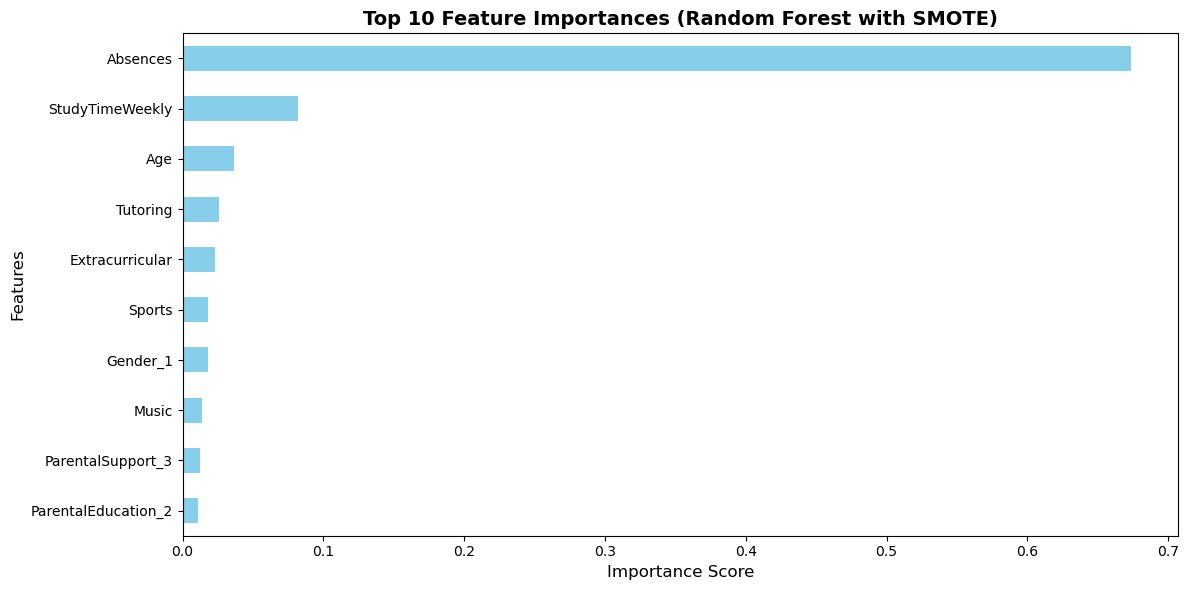

In [66]:
# Plot Top 10 Feature Importances
plt.figure(figsize=(12, 6))
feat_importances.head(10).plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest with SMOTE)", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

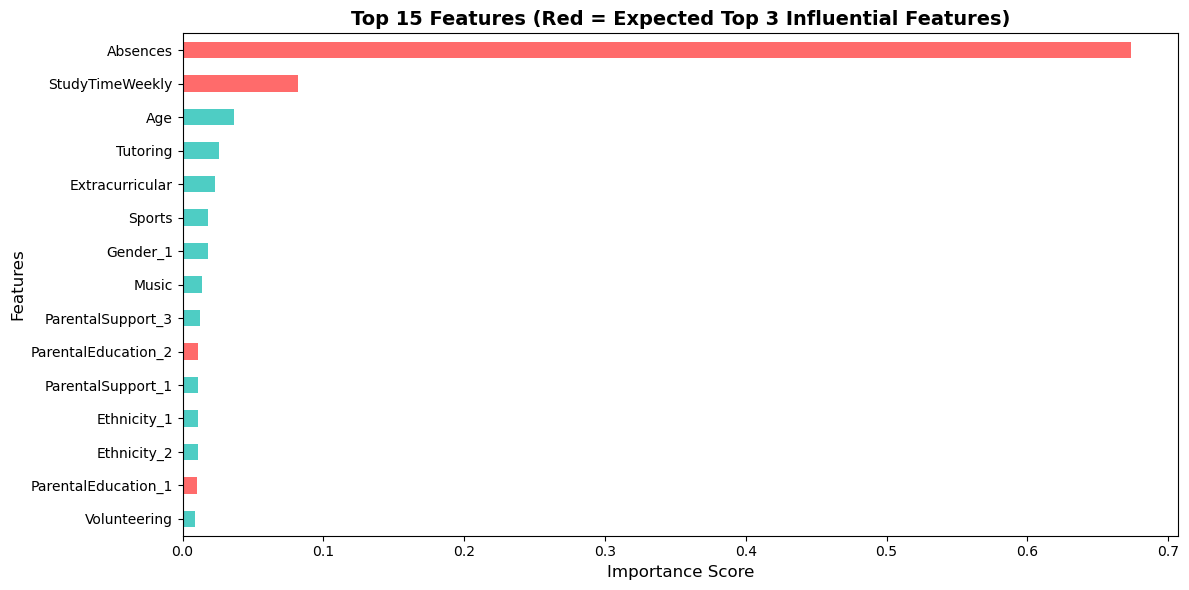

In [67]:
# Highlight Top 3 Expected Features
expected_features = ['StudyTimeWeekly', 'Absences']
parental_ed_features = [f for f in feature_names if 'ParentalEducation' in f]

plt.figure(figsize=(12, 6))
colors = ['#FF6B6B' if any(exp in feat for exp in expected_features) or 
          any(exp in feat for exp in parental_ed_features) 
          else '#4ECDC4' for feat in feat_importances.head(15).index]

feat_importances.head(15).plot(kind='barh', color=colors)
plt.gca().invert_yaxis()
plt.title("Top 15 Features (Red = Expected Top 3 Influential Features)", 
          fontsize=14, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

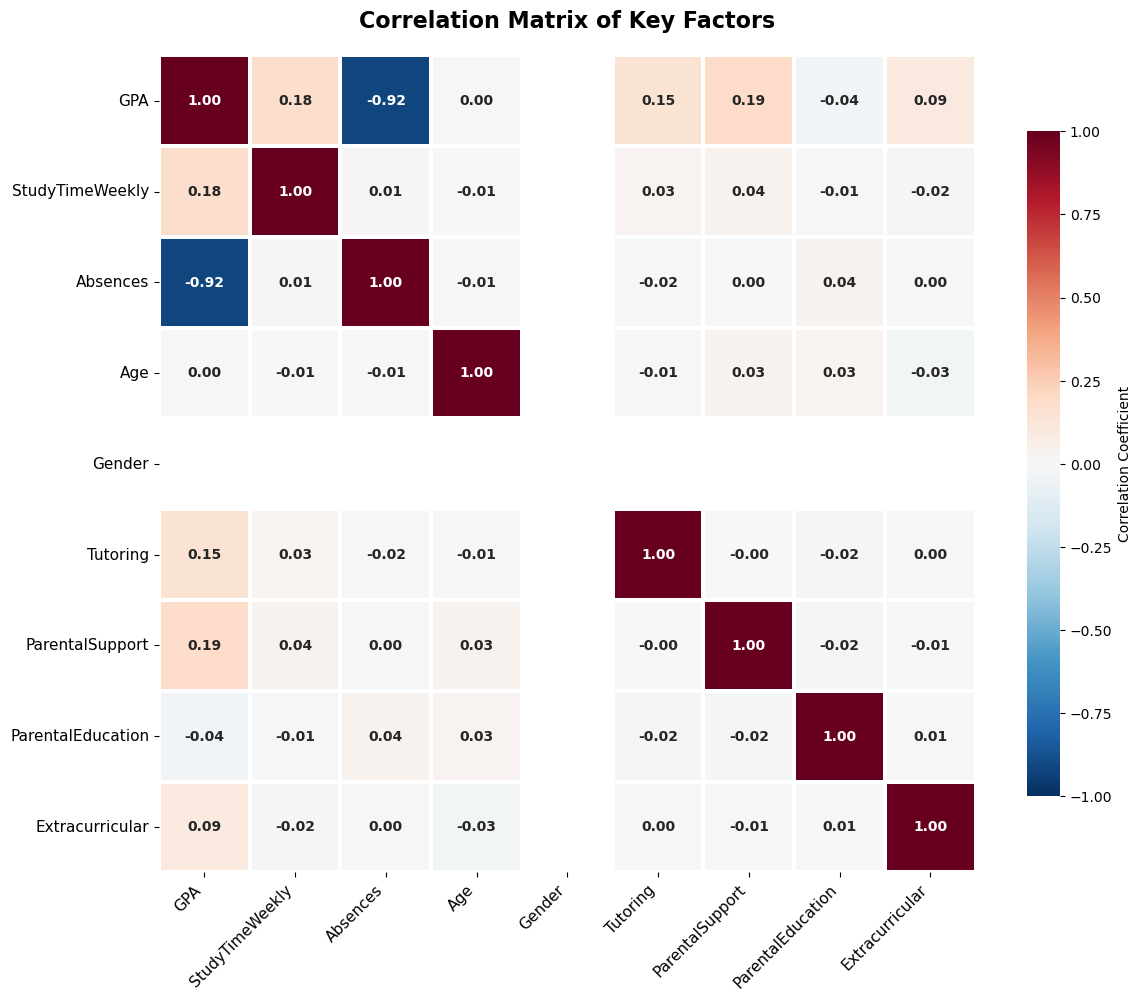

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Student_performance_data _.csv')

# Create a copy for correlation analysis
df_corr = df.copy()

# Encode categorical variables
# Gender encoding
if 'Gender' in df_corr.columns:
    df_corr['Gender'] = df_corr['Gender'].map({'Male': 1, 'Female': 0})

# ParentalEducation encoding (ordinal)
if 'ParentalEducation' in df_corr.columns:
    education_order = ['None', 'High School', 'Some College', "Bachelor's", 'Higher']
    education_mapping = {edu: idx for idx, edu in enumerate(education_order)}
    
    # If the exact values don't match, create mapping from unique values
    if not all(val in education_mapping for val in df_corr['ParentalEducation'].unique()):
        unique_vals = sorted(df_corr['ParentalEducation'].unique())
        education_mapping = {val: idx for idx, val in enumerate(unique_vals)}
    
    df_corr['ParentalEducation'] = df_corr['ParentalEducation'].map(education_mapping)

# ParentalSupport encoding (ordinal)
if 'ParentalSupport' in df_corr.columns:
    support_order = ['None', 'Low', 'Medium', 'High', 'Very High']
    support_mapping = {sup: idx for idx, sup in enumerate(support_order)}
    
    # If the exact values don't match, create mapping from unique values
    if not all(val in support_mapping for val in df_corr['ParentalSupport'].unique()):
        unique_vals = sorted(df_corr['ParentalSupport'].unique())
        support_mapping = {val: idx for idx, val in enumerate(unique_vals)}
    
    df_corr['ParentalSupport'] = df_corr['ParentalSupport'].map(support_mapping)

# Select key features for correlation matrix
key_features = [
    'GPA',
    'StudyTimeWeekly',
    'Absences',
    'Age',
    'Gender',
    'Tutoring',
    'ParentalSupport',
    'ParentalEducation',
    'Extracurricular'
]

# Filter only available features
available_features = [feat for feat in key_features if feat in df_corr.columns]

# Calculate correlation matrix
correlation_matrix = df_corr[available_features].corr()

# Create the correlation heatmap
plt.figure(figsize=(12, 10))

# Create heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,           # Show numbers
    fmt='.2f',            # Format: 2 decimal places
    cmap='RdBu_r',        # Color scheme: Red (positive) to Blue (negative)
    center=0,             # Center the colormap at 0
    square=True,          # Square cells
    linewidths=1.5,       # Grid line width
    linecolor='white',    # Grid line color
    cbar_kws={
        'label': 'Correlation Coefficient',
        'shrink': 0.8,
        'ticks': [-1.00, -0.75, -0.50, -0.25, 0.00, 0.25, 0.50, 0.75, 1.00]
    },
    vmin=-1,              # Minimum value
    vmax=1,               # Maximum value
    annot_kws={'size': 10, 'weight': 'bold'}  # Annotation style
)

# Customize title
plt.title('Correlation Matrix of Key Factors', 
          fontsize=16, 
          fontweight='bold', 
          pad=20)

# Rotate labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()




CONFUSION MATRIX


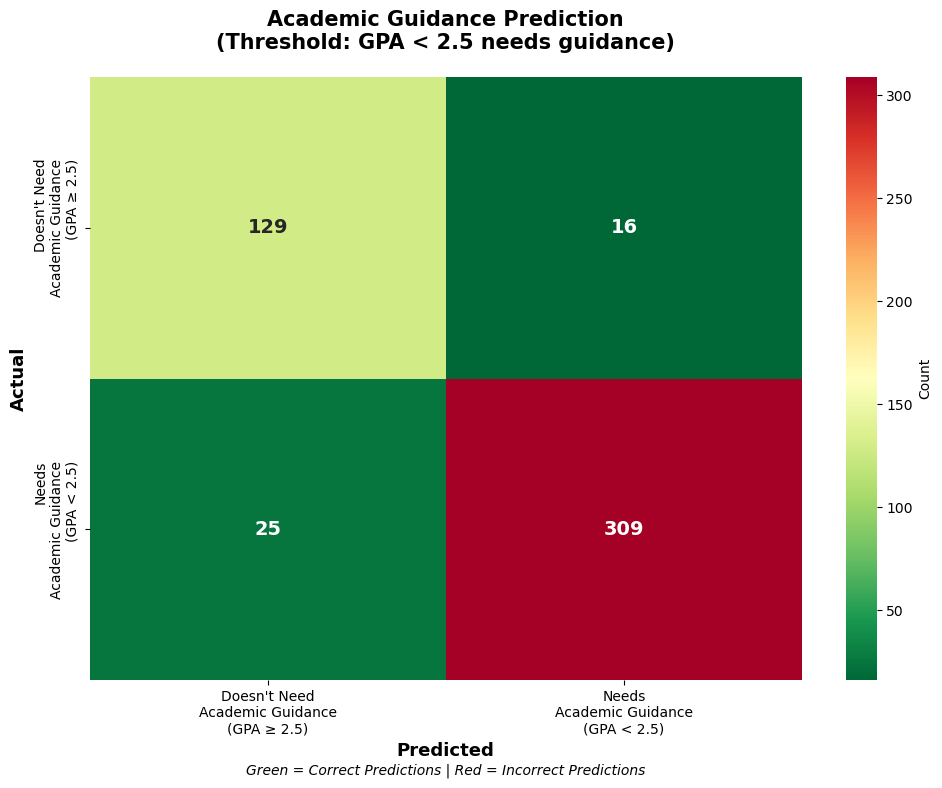


Confusion Matrix Breakdown:
True Negatives (Correctly predicted NO guidance needed): 129
False Positives (Incorrectly predicted NEEDS guidance): 16
False Negatives (Incorrectly predicted NO guidance needed): 25
True Positives (Correctly predicted NEEDS guidance): 309


In [69]:
# Print confusion matrix interpretation
# Confusion Matrix
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_smote)

# Create custom labels
labels = [
    "Doesn't Need\nAcademic Guidance\n(GPA ≥ 2.5)",
    "Needs\nAcademic Guidance\n(GPA < 2.5)"
]

sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', 
            xticklabels=labels, 
            yticklabels=labels,
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 14, 'weight': 'bold'})

plt.xlabel('Predicted', fontsize=13, fontweight='bold')
plt.ylabel('Actual', fontsize=13, fontweight='bold')
plt.title(f'Academic Guidance Prediction\n(Threshold: GPA < {threshold} needs guidance)', 
          fontsize=15, fontweight='bold', pad=20)

# Add text annotation for interpretation
plt.text(0.5, -0.15, 
         'Green = Correct Predictions | Red = Incorrect Predictions',
         ha='center', va='center', transform=plt.gca().transAxes,
         fontsize=10, style='italic')

plt.tight_layout()
plt.show()

# Print confusion matrix interpretation
print("\nConfusion Matrix Breakdown:")
print(f"True Negatives (Correctly predicted NO guidance needed): {cm[0][0]}")
print(f"False Positives (Incorrectly predicted NEEDS guidance): {cm[0][1]}")
print(f"False Negatives (Incorrectly predicted NO guidance needed): {cm[1][0]}")
print(f"True Positives (Correctly predicted NEEDS guidance): {cm[1][1]}")


CORRELATION WITH GPA

Correlation with GPA:
GPA                1.000000
StudyTimeWeekly    0.179275
Tutoring           0.145119
Extracurricular    0.094078
Music              0.073318
Sports             0.057859
Volunteering       0.003258
Age                0.000275
Absences          -0.919314
Name: GPA, dtype: float64


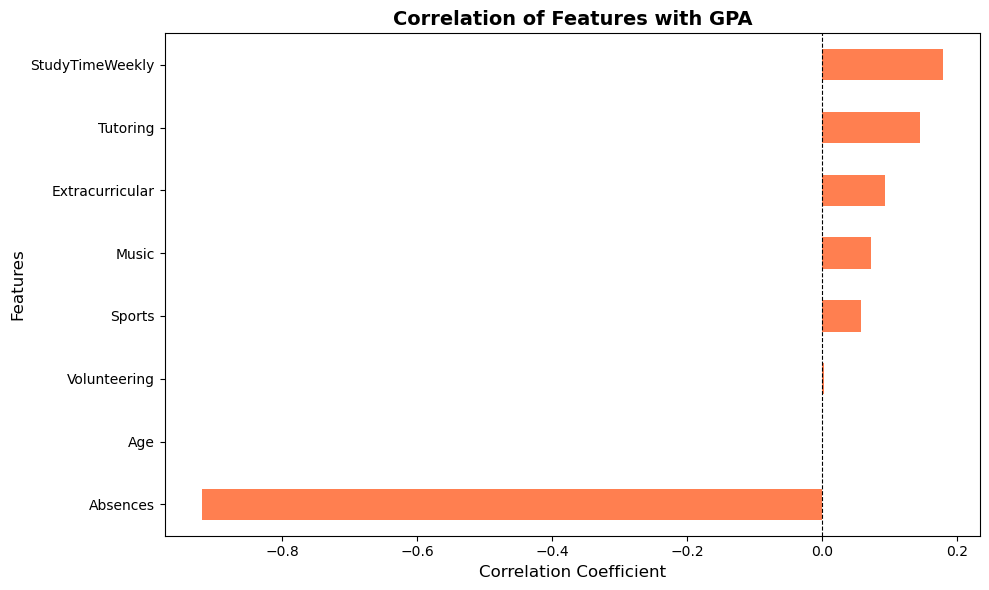

In [70]:
# Additional Analysis: Check correlation with GPA
print("\n" + "="*50)
print("CORRELATION WITH GPA")
print("="*50)

# Reload data for correlation analysis
df_corr = pd.read_csv('Student_performance_data _.csv')
numerical_features = ['Age', 'StudyTimeWeekly', 'Absences', 'Tutoring', 
                      'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA']

correlation_with_gpa = df_corr[numerical_features].corr()['GPA'].sort_values(ascending=False)
print("\nCorrelation with GPA:")
print(correlation_with_gpa)

# Plot correlations
plt.figure(figsize=(10, 6))
correlation_with_gpa.drop('GPA').plot(kind='barh', color='coral')
plt.gca().invert_yaxis()
plt.title("Correlation of Features with GPA", fontsize=14, fontweight='bold')
plt.xlabel("Correlation Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

Correlation between Absences and GPA: -0.9193


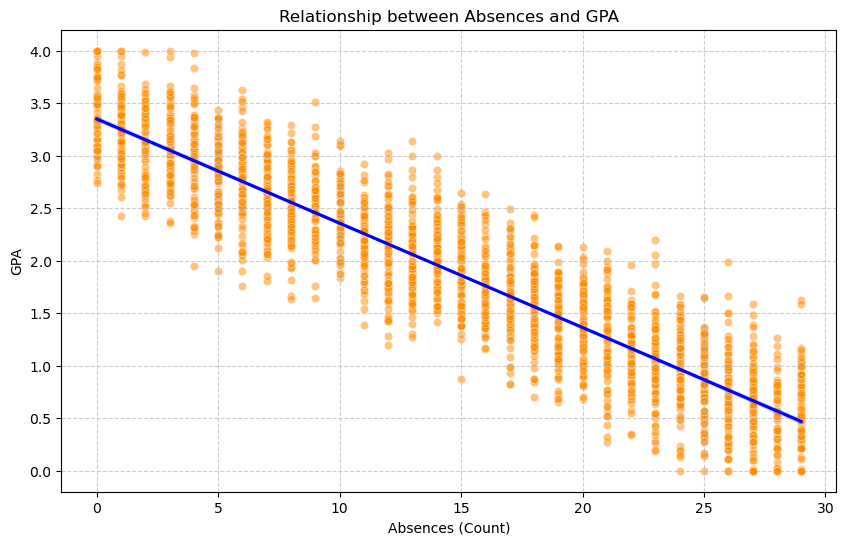

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Loading and Preparation ---
df = pd.read_csv('Student_performance_data _.csv')

# Imputation
numeric_cols = ['Absences', 'GPA']
for col in numeric_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# --- 2. Analysis and Visualization ---

# Calculate Correlation
correlation = df['Absences'].corr(df['GPA'])
print(f"Correlation between Absences and GPA: {correlation:.4f}")

plt.figure(figsize=(10, 6))
# Create Scatter Plot
sns.scatterplot(x='Absences', y='GPA', data=df, alpha=0.5, color='darkorange')

# Add Trendline
sns.regplot(x='Absences', y='GPA', data=df, scatter=False, color='blue', 
            line_kws={'label': f'Trend (Corr: {correlation:.2f})'})

plt.title('Relationship between Absences and GPA')
plt.xlabel('Absences (Count)')
plt.ylabel('GPA')
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('absences_vs_gpa.png')
plt.show()

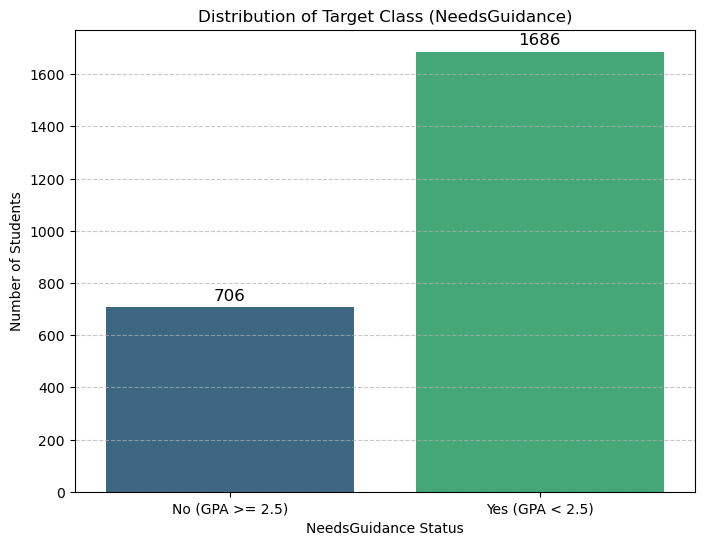

Class Counts:
NeedsGuidance
1    1686
0     706
Name: count, dtype: int64


In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Imputation for 'GPA' if there are missing values (safety check)
if df['GPA'].isnull().any():
    df['GPA'].fillna(df['GPA'].median(), inplace=True)

# Create the target variable based on the threshold
# GPA < 2.5 means the student needs guidance (Target = 1)
threshold = 2.5
df['NeedsGuidance'] = (df['GPA'] < threshold).astype(int)

# --- 2. Visualization ---

plt.figure(figsize=(8, 6))

# Updated countplot call:
# - Set hue='NeedsGuidance' to fix the deprecation warning
# - Set dodge=False to keep bars centered like a standard bar chart
ax = sns.countplot(x='NeedsGuidance', data=df, hue='NeedsGuidance', palette='viridis', dodge=False)

# Manually remove the legend (since x and hue are the same, it's redundant)
if ax.legend_:
    ax.legend_.remove()

# Add descriptive titles and labels
plt.title('Distribution of Target Class (NeedsGuidance)')
plt.xlabel('NeedsGuidance Status')
plt.ylabel('Number of Students')

# Rename the x-axis ticks to be more readable
plt.xticks([0, 1], ['No (GPA >= 2.5)', 'Yes (GPA < 2.5)'])

# Add the exact count numbers on top of the bars for clarity
for p in ax.patches:
    # Ensure height is a number before annotating
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', 
                    fontsize=12, color='black', 
                    xytext=(0, 5), textcoords='offset points')

# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save and show the plot
plt.savefig('target_class_distribution_fixed_v2.png')
plt.show()

# Print the exact counts to console
print("Class Counts:")
print(df['NeedsGuidance'].value_counts())

Correlation between StudyTimeWeekly and GPA: 0.1793


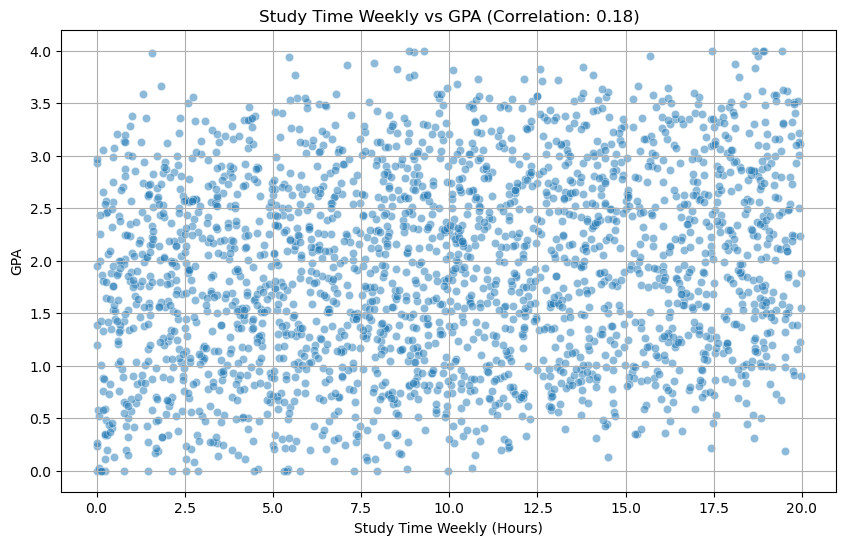

In [73]:

import matplotlib.pyplot as plt
import seaborn as sns


# Imputation (Filling missing values with median to handle potential NAs)
numeric_cols = ['StudyTimeWeekly', 'GPA']
for col in numeric_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# --- 2. Statistical Analysis ---

# Calculate Pearson Correlation Coefficient
correlation = df['StudyTimeWeekly'].corr(df['GPA'])
print(f"Correlation between StudyTimeWeekly and GPA: {correlation:.4f}")

# --- 3. Visualization ---

plt.figure(figsize=(10, 6))
# Create a scatter plot
sns.scatterplot(x='StudyTimeWeekly', y='GPA', data=df, alpha=0.5)

# Add title and labels
plt.title(f'Study Time Weekly vs GPA (Correlation: {correlation:.2f})')
plt.xlabel('Study Time Weekly (Hours)')
plt.ylabel('GPA')

# Add grid for readability
plt.grid(True)

# Save the plot
plt.savefig('study_vs_gpa.png')
plt.show()

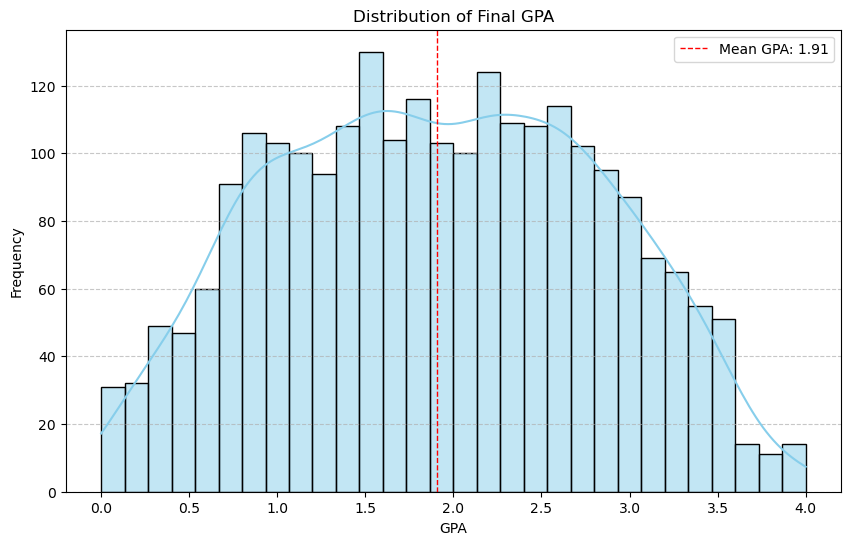


--- GPA Statistics ---
count    2392.000000
mean        1.906186
std         0.915156
min         0.000000
25%         1.174803
50%         1.893393
75%         2.622216
max         4.000000
Name: GPA, dtype: float64


In [74]:

import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Loading and Preparation ---

# Load the dataset
df = pd.read_csv('Student_performance_data _.csv')

# Imputation (Filling missing GPA values with median if any exist)
if df['GPA'].isnull().any():
    df['GPA'].fillna(df['GPA'].median(), inplace=True)

# --- 2. Visualization (Histogram) ---

plt.figure(figsize=(10, 6))
# Create histogram with Kernel Density Estimate (KDE)
sns.histplot(df['GPA'], kde=True, bins=30, color='skyblue')

# Add titles and labels
plt.title('Distribution of Final GPA')
plt.xlabel('GPA')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a vertical line for the mean GPA
mean_gpa = df['GPA'].mean()
plt.axvline(mean_gpa, color='red', linestyle='dashed', linewidth=1, label=f'Mean GPA: {mean_gpa:.2f}')
plt.legend()

# Save the plot
plt.savefig('gpa_distribution.png')
plt.show()

# --- 3. Statistics ---

print("\n--- GPA Statistics ---")
print(df['GPA'].describe())

In [86]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score



models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight='balanced')
}

results_list = []

print("--- Model Results Output ---")

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # Store results
    results_list.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision (Class 1)': report['1']['precision'],
        'Recall (Class 1)': report['1']['recall'],
        'F1-Score (Class 1)': report['1']['f1-score'],
        'ROC-AUC': roc_auc
    })
    
    # Print Classification Report
    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))

# --- 3. Summary Table ---
df_results = pd.DataFrame(results_list)
print("\n--- Final Results Summary Table ---")
print(df_results.to_markdown(index=False, floatfmt=".4f"))

--- Model Results Output ---

Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.96      0.90       145
           1       0.98      0.92      0.95       334

    accuracy                           0.93       479
   macro avg       0.91      0.94      0.92       479
weighted avg       0.94      0.93      0.93       479


Model: Decision Tree
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       145
           1       0.96      0.90      0.93       334

    accuracy                           0.90       479
   macro avg       0.88      0.90      0.89       479
weighted avg       0.91      0.90      0.91       479


Model: Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       145
           1       0.95      0.92      0.94       334

    accuracy                           0.91       479
   macro avg       0.89    